Make Regression

In [1]:
from sklearn.datasets import make_regression
import seaborn as sns

In [2]:
x, y = make_regression(n_features=10, n_samples=200, n_targets=1)

In [3]:
x.shape

(200, 10)

In [4]:
x

array([[-0.27209796, -1.07238072, -1.27434981, ..., -0.45121085,
         0.89957416, -1.45415764],
       [-1.89828027,  0.52477176,  0.22549845, ...,  0.81361879,
         0.05196704, -0.37684469],
       [-1.3113458 ,  0.10630091, -1.72884441, ..., -0.47259441,
        -0.76591161,  0.35391198],
       ...,
       [ 1.48975433,  0.74933348,  0.05468158, ...,  1.29768692,
         0.33581925,  0.44695182],
       [-0.5681002 ,  1.01705445,  0.69440673, ...,  0.36275932,
        -1.9987998 , -0.2827321 ],
       [-1.19525424, -1.19565971,  0.42467586, ...,  1.14485407,
        -1.67810505,  0.38708787]], shape=(200, 10))

In [5]:
y.shape

(200,)

In [6]:
import pandas as pd
df = pd.DataFrame(x, y)
df.head()

,0,1,2,3,4,5,6,7,8,9
-10.019379,-0.272098,-1.072381,-1.274350,-0.763473,0.323493,0.990579,0.364272,-0.451211,0.899574,-1.454158
-65.060646,-1.898280,0.524772,0.225498,-1.457347,-1.028174,0.232426,-0.294083,0.813619,0.051967,-0.376845
-228.294668,-1.311346,0.106301,-1.728844,0.647427,-1.553679,0.017878,0.567256,-0.472594,-0.765912,0.353912
70.919535,-1.314739,1.231107,1.983405,-0.887877,-0.874874,0.225706,-0.181024,1.095022,-0.637047,0.266872
-217.063034,-1.367059,2.049623,-1.547599,0.235229,-0.992637,0.179976,-1.434124,0.166201,-1.530901,1.177902


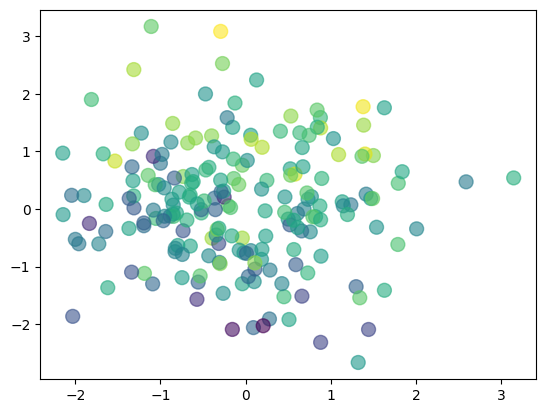

In [7]:
import matplotlib.pyplot as plt
plt.scatter(x[:, 0], x[:, 5], c=y, s=100, alpha=0.6)

Make Regression

In [8]:
from sklearn.datasets import make_classification

In [9]:
n_x, n_y = make_classification(n_samples=2000, n_features=7, n_classes=2)

In [10]:
n_x.shape

(2000, 7)

In [11]:
n_x

array([[-1.89391251, -1.55200236,  0.17850814, ..., -2.06116879,
         0.05712981, -0.79438414],
       [-1.28127181,  2.39268263, -1.22209012, ..., -0.62566736,
         1.68666054, -0.01899948],
       [-0.63856591,  1.36586695,  0.79636037, ...,  1.80802561,
         2.54586544,  0.52695809],
       ...,
       [-1.0596523 , -0.58164745,  0.92739934, ...,  0.38152097,
         0.72128434, -0.22762061],
       [ 1.35070299,  0.10865442,  1.81755688, ...,  0.77059435,
         0.77869592,  0.82431277],
       [-0.93898416, -0.71131331,  1.51196093, ...,  1.46197872,
         0.63920604, -0.20168198]], shape=(2000, 7))

In [12]:
df2 = pd.DataFrame(n_x, n_y)
df2.head()

,0,1,2,3,4,5,6
0,-1.893913,-1.552002,0.178508,-1.490034,-2.061169,0.057130,-0.794384
0,-1.281272,2.392683,-1.222090,-0.999849,-0.625667,1.686661,-0.018999
0,-0.638566,1.365867,0.796360,-0.489834,1.808026,2.545865,0.526958
0,-3.397739,0.253754,0.488826,-2.674618,1.587229,-0.189513,-1.517007
0,-0.848938,-0.472704,-1.235245,-0.662734,0.142358,1.065180,-0.029059


In [13]:
df3 = pd.DataFrame(n_y)
df3.value_counts()

0
1    1004
0     996
Name: count, dtype: int64

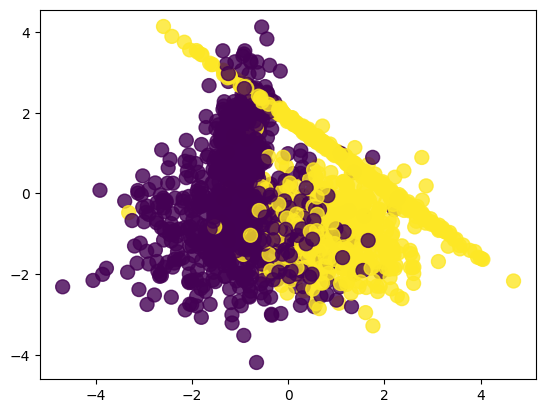

In [14]:
plt.scatter(n_x[:,0], n_x[:,5], c=n_y, s=100, alpha=0.8)

Make circle

In [15]:
import pandas as pd
import numpy as np
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC
from sklearn.datasets import make_circles

In [16]:
n_y

array([0, 0, 0, ..., 0, 1, 0], shape=(2000,))

In [17]:
X, y = make_circles(200, factor=.3, noise=.1)

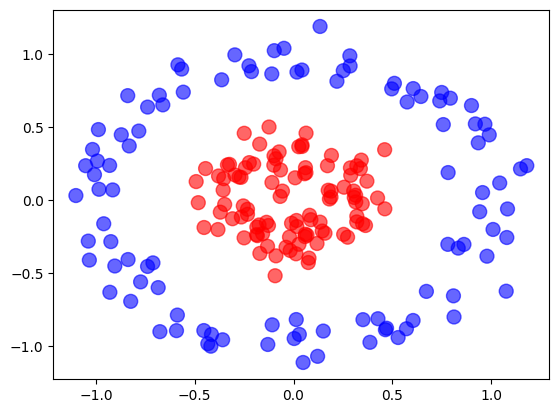

In [18]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, cmap="bwr", alpha=0.6)

In [21]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
classifier = SVC(kernel='linear')
classifier.fit(Xtrain, Ytrain.ravel())
y_pred = classifier.predict(Xtest)

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(Ytest, y_pred)

0.575

In [20]:
zero_one_colormap = ListedColormap(['green', 'red'])
def plot_decision_boundry(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(
        np.arange(
            start=X_set[:, 1].min()-1,
            stop = X_set[:, 1].max()+1,
            step = 0.01
        ),
        np.arange(
            start= X_set[:, 1].min()-1,
            stop = X_set[:, 1].max()+1,
            step = 0.01
        )
    )

    plt.contourf(
        X1, X2, 
        clf.predict(
            np.array([X1.ravel(), X2.ravel()]).T
        ).reshape(X1.shape),
        alpha=0.75,
        cmap= zero_one_colormap
    )
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            X_set[y_set == j,0], 
            X_set[y_set == j, 1],
            c= (zero_one_colormap)(i), label=j
        )
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\MD Maruf\AppData\Local\Temp\ipykernel_16260\2972229817.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


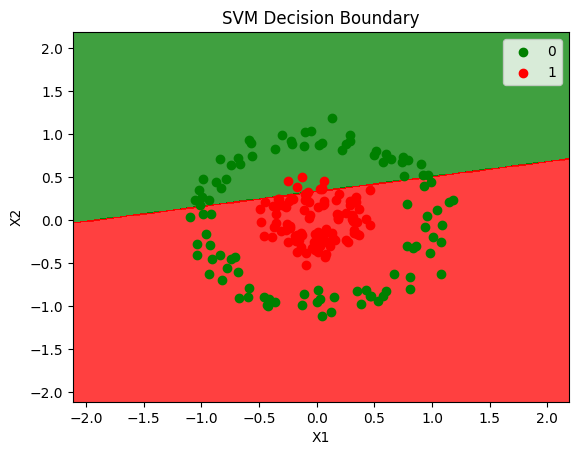

In [24]:
plot_decision_boundry(X, y, classifier)

In [28]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

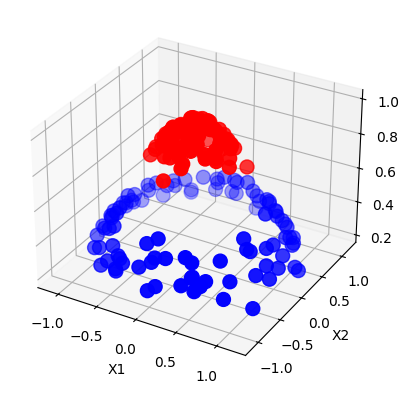

In [29]:
plot_3d_plot(X, y)

In [30]:
# RBF kernel 
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(Xtrain, Ytrain)
rbf_pred = rbf_classifier.predict(Xtest)
accuracy_score(Ytest, rbf_pred)

1.0

C:\Users\MD Maruf\AppData\Local\Temp\ipykernel_16260\2972229817.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


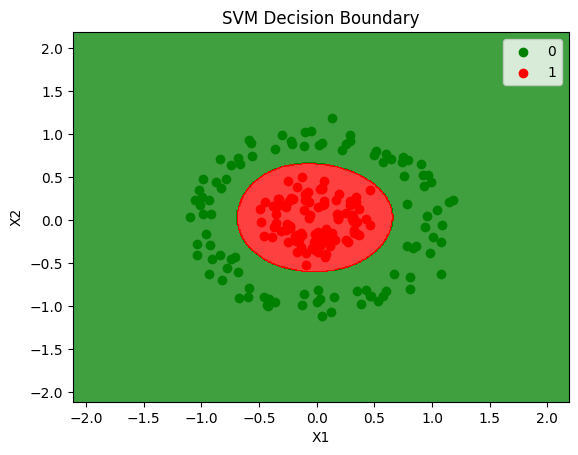

In [31]:
plot_decision_boundry(X, y, rbf_classifier)

In [34]:
# Rpoly kernel 
poly_classifier = SVC(kernel='poly', degree=2)
poly_classifier.fit(Xtrain, Ytrain)
poly_pred = poly_classifier.predict(Xtest)
accuracy_score(Ytest, poly_pred)

1.0

C:\Users\MD Maruf\AppData\Local\Temp\ipykernel_16260\2972229817.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


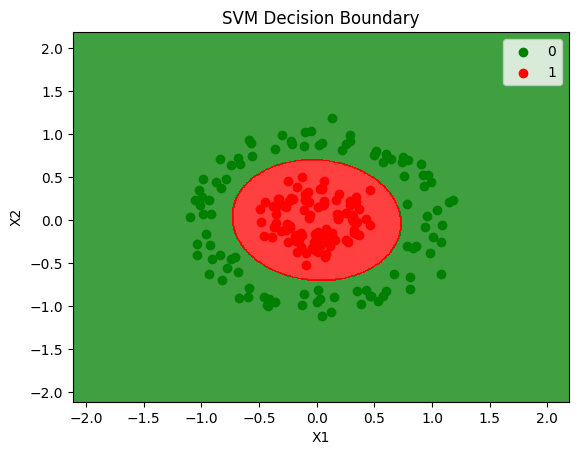

In [35]:
plot_decision_boundry(X, y, poly_classifier)